### load

In [1]:
import numpy as np
import pandas as pd
import polars as pl
from polars import selectors as cs
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OrdinalEncoder, OneHotEncoder, TargetEncoder, Binarizer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import train_test_split,cross_validate,KFold,GridSearchCV
from sklearn.metrics import root_mean_squared_log_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.utils.validation import check_is_fitted
from category_encoders import CountEncoder
%matplotlib inline

from add_features import add_modified_features

In [2]:
train = pl.read_csv('../data/train.csv',infer_schema_length=None,null_values='NA')
test = pl.read_csv('../data/test.csv',infer_schema_length=None,null_values = 'NA')

print(train.shape, test.shape)

(1460, 81) (1459, 80)


In [3]:
drop = [
    'Id',
    '2ndFlrSF',
    '1stFlrSF',
]

X = train.select(cs.exclude(drop,'SalePrice'))
y = train['SalePrice']

X_test = test.select(cs.exclude(drop,'SalePrice'))
X.glimpse()

Rows: 1460
Columns: 77
$ MSSubClass    <i64> 60, 20, 60, 70, 60, 50, 20, 60, 50, 190
$ MSZoning      <str> 'RL', 'RL', 'RL', 'RL', 'RL', 'RL', 'RL', 'RL', 'RM', 'RL'
$ LotFrontage   <i64> 65, 80, 68, 60, 84, 85, 75, null, 51, 50
$ LotArea       <i64> 8450, 9600, 11250, 9550, 14260, 14115, 10084, 10382, 6120, 7420
$ Street        <str> 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave', 'Pave'
$ Alley         <str> null, null, null, null, null, null, null, null, null, null
$ LotShape      <str> 'Reg', 'Reg', 'IR1', 'IR1', 'IR1', 'IR1', 'Reg', 'IR1', 'Reg', 'Reg'
$ LandContour   <str> 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl', 'Lvl'
$ Utilities     <str> 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub'
$ LotConfig     <str> 'Inside', 'FR2', 'Inside', 'Corner', 'FR2', 'Inside', 'Inside', 'Corner', 'Inside', 'Corner'
$ LandSlope     <str> 'Gtl', 'Gtl', 'Gtl', 'Gtl', 'Gtl', 'Gtl', 'Gtl', 'Gtl', 'Gtl', 

### explore

In [4]:
train.describe()

statistic,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,…,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
str,f64,f64,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,str,str,str,str,str,f64,str,str,str,str,str,str,str,f64,str,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,str,str,str,f64,f64,f64,str,str,f64
"""count""",1460.0,1460.0,"""1460""",1201.0,1460.0,"""1460""","""91""","""1460""","""1460""","""1460""","""1460""","""1460""","""1460""","""1460""","""1460""","""1460""","""1460""",1460.0,1460.0,1460.0,1460.0,"""1460""","""1460""","""1460""","""1460""","""1452""",1452.0,"""1460""","""1460""","""1460""","""1423""","""1423""","""1422""","""1423""",1460.0,"""1422""",…,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,"""1460""",1460.0,"""1460""",1460.0,"""770""","""1379""",1379.0,"""1379""",1460.0,1460.0,"""1379""","""1379""","""1460""",1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,"""7""","""281""","""54""",1460.0,1460.0,1460.0,"""1460""","""1460""",1460.0
"""null_count""",0.0,0.0,"""0""",259.0,0.0,"""0""","""1369""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""8""",8.0,"""0""","""0""","""0""","""37""","""37""","""38""","""37""",0.0,"""38""",…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,"""0""",0.0,"""690""","""81""",81.0,"""81""",0.0,0.0,"""81""","""81""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""1453""","""1179""","""1406""",0.0,0.0,0.0,"""0""","""0""",0.0
"""mean""",730.5,56.89726,null,70.049958,10516.828082,null,null,null,null,null,null,null,null,null,null,null,null,6.099315,5.575342,1971.267808,1984.865753,null,null,null,null,null,103.685262,null,null,null,null,null,null,null,443.639726,null,…,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,null,6.517808,null,0.613014,null,null,1978.506164,null,1.767123,472.980137,null,null,null,94.244521,46.660274,21.95411,3.409589,15.060959,2.758904,null,null,null,43.489041,6.321918,2007.815753,null,null,180921.19589
"""std""",421.610009,42.300571,null,24.284752,9981.264932,null,null,null,null,null,null,null,null,null,null,null,null,1.382997,1.112799,30.202904,20.645407,null,null,null,null,null,181.066207,null,null,null,null,null,null,null,456.098091,null,…,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,null,1.625393,null,0.644666,null,null,24.689725,null,0.747315,213.804841,null,null,null,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,null,null,null,496.123024,2.703626,1.328095,null,null,79442.502883
"""min""",1.0,20.0,"""C (all)""",21.0,1300.0,"""Grvl""","""Grvl""","""IR1""","""Bnk""","""AllPub""","""Corner""","""Gtl""","""Blmngtn""","""Artery""","""Artery""","""1Fam""","""1.5Fin""",1.0,1.0,1872.0,1950.0,"""Flat""","""ClyTile""","""AsbShng""","""AsbShng""","""BrkCmn""",0.0,"""Ex""","""Ex""","""BrkTil""","""Ex""","""Fa""","""Av""","""ALQ""",0.0,"""ALQ""",…,0.0,0.0,334.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Ex""",2.0,"""Maj1""",0.0,"""Ex""","""2Types""",1900.0,"""Fin""",0.0,0.0,"""Ex""","""Ex""","""N""",0.0,0.0,0.0,0.0,0.0,0.0,"""Ex""","""GdPrv""","""Gar2""",0.0,1.0,2006.0,"""COD""","""Abnorml""",34900.0
"""25%""",366.0,20.0,null,59.0,7558.0,null,null,null,

In [5]:
nulls = train.select(cs.numeric()).to_pandas().isna().sum()
nulls[nulls > 0]

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

### col-prep mapping

In [6]:
map_label = {
    'Street': {'Pave':1,'Grvl':0},
    'CentralAir': {'Y':1, 'N':0},
}

eq_val_label = {
    'Heating': 'GasA',
    'PavedDrive': 'Y',
    'RoofMatl': 'ClyTile',
    'Condition2':'PosN',
    'SaleCondition':'Normal',
    'LandContour':'Lvl',    
}

is_na_label = [
    'Alley',
    'PoolQC',
    'Fence',
    'MiscFeature',
]

is_zero_label = [
    'LowQualFinSF',
    'BsmtFinSF2',
    'PoolArea',
    'BsmtHalfBath',
    'ScreenPorch',
    '3SsnPorch',
    'MiscVal',
]


# 欠損 = データ不備（最頻値で補完）
ordinal_encoded_data_error = {
    'KitchenQual':['Po','Fa','TA','Gd','Ex'],
    'Functional':['Typ','Min1', 'Min2', 'Mod', 'Maj1', 'Maj2', 'Sev', 'Sal'],
}

# 欠損 = 該当設備なし（"Missing"で補完）
ordinal_encoded_no_feature = {
    'FireplaceQu':['Missing', 'Po','Fa','TA','Gd','Ex'],
    'GarageQual':['Missing', 'Po','Fa','TA','Gd','Ex'],
    'GarageCond': ['Missing', 'Po','Fa','TA','Gd','Ex'],
    'LotShape':['Reg','IR1','IR2','IR3'],
}

one_hot_encoded = [  # 最頻値で補完
    'Utilities',
    'LotConfig',
    'LandSlope',
    'Condition1',
    'Condition2',
    'BldgType',
    'HouseStyle',
    'RoofStyle',
    'RoofMatl',
    'Exterior2nd',
    'ExterQual',
    'ExterCond',
    'Foundation',
    'HeatingQC',
    'SaleType',
    'Electrical',
    'MasVnrType',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'GarageType',
    'GarageFinish',
]

target_encoded = [
    'MSSubClass',
    'Neighborhood',
]

count_encoded = [  # 最頻値で補完
    'Exterior1st',
    'MSZoning', 
]

log_standardized = [ # 中央値で補完
    'LotFrontage',
    'LotArea',
    'YearBuilt',
    'GrLivArea',
    'BsmtUnfSF',
    'TotalBsmtSF',
    'BsmtFinSF1',
    'MasVnrArea',
    'EnclosedPorch',
    'HalfBath',
    'OpenPorchSF',
    'WoodDeckSF',
    # 追加
    'TotalFlrSF',
    'BsmtAboveRatio',
    'LivLotRatio',
]

standardized = [ # 中央値で補完
    'OverallQual',
    'OverallCond',
    'BsmtFullBath',
    'FullBath',
    'BedroomAbvGr',
    'KitchenAbvGr',
    'TotRmsAbvGrd',
    'Fireplaces',
    'GarageYrBlt',
    'GarageCars',
    'GarageArea',
    'MoSold',
    'YrSold',
    'OverallScore',
    'BathScore',
    'BuildingAgeAtSale',
    'IsOverAllGE9',
    'SoldAfterRehman',
    'SoldMay2June',]


### pipeline

In [7]:
# ---------Target-Pipeline----------- #

log_standardize_y = Pipeline([
    ("log", FunctionTransformer(np.log1p, inverse_func=np.expm1, check_inverse=False)),
    ("scale", StandardScaler())
])

# ---------Features-Pipeline----------- #

log_standardize = Pipeline([
    ("log", FunctionTransformer(np.log1p, inverse_func=np.expm1, check_inverse=False, feature_names_out="one-to-one")),
    ("scale", StandardScaler())
])

# map_label: 明示的な値->コードのマッピング（Street, CentralAir）
map_label_pipeline = Pipeline([
    ("ordinal", OrdinalEncoder(categories=[
        sorted(mapping, key=mapping.get) for mapping in map_label.values()
    ])),
    ("scale", StandardScaler()),
])

# eq_val_label: 指定値と一致するかどうかの2値化（Heating, PavedDrive）
eq_val_label_pipeline = Pipeline([
    ("eq", FunctionTransformer(
        lambda X, values=list(eq_val_label.values()): (np.asarray(X) == values).astype(int),
        feature_names_out="one-to-one",
    )),
    ("scale", StandardScaler()),
])

# is_na_label: 欠損（＝その設備なし）を示す2値フラグ
is_na_label_pipeline = Pipeline([
    ("indicator", MissingIndicator(features="all", missing_values=None)),
    ("scale", StandardScaler()),
])

# is_zero_label: 0でないかを示す2値フラグ
is_zero_label_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value=0)),
    ("binarize", Binarizer(threshold=0)),
    ("scale", StandardScaler()),
])

# ordinal_encoded_data_error: 欠損はデータ不備のため最頻値で補完してから順序エンコード
# ※ Functionalのみ Typ=0 を基準に悪化するほど負の値になるよう符号を反転する
ordinal_data_error_sign = np.array([-1 if col == 'Functional' else 1 for col in ordinal_encoded_data_error])

ordinal_encoded_data_error_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent", missing_values=None)),
    ("ordinal", OrdinalEncoder(categories=list(ordinal_encoded_data_error.values()))),
    ("sign", FunctionTransformer(
        lambda X: np.asarray(X) * ordinal_data_error_sign,
        feature_names_out="one-to-one",
    )),
])

# ordinal_encoded_no_feature: 欠損は該当設備なしを意味するので"Missing"で補完してから順序エンコード
ordinal_encoded_no_feature_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Missing", missing_values=None)),
    ("ordinal", OrdinalEncoder(categories=list(ordinal_encoded_no_feature.values()))),
])

# one_hot_encoded: 最頻値で補完してからOne-Hotエンコード
one_hot_encoded_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent", missing_values=None)),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# target_encoded: 最頻値で補完してからターゲットエンコード
target_encoded_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent", missing_values=None)),
    ("target", TargetEncoder()),
    ("scale", StandardScaler())
])

# count_encoded: 最頻値で補完してからカウントエンコード
count_encoded_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent", missing_values=None)),
    ("count", CountEncoder()),
])

# log_standardized: 中央値で補完してから対数変換+標準化
log_standardized_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("log_standard", log_standardize),
])

# standardized: 中央値で補完してから標準化
standardized_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

In [8]:
preprocessor = ColumnTransformer([
    ("map_label", map_label_pipeline, list(map_label.keys())),
    ("eq_val_label", eq_val_label_pipeline, list(eq_val_label.keys())),
    ("is_na_label", is_na_label_pipeline, is_na_label),
    ("is_zero_label", is_zero_label_pipeline, is_zero_label),
    ("ordinal_encoded_data_error", ordinal_encoded_data_error_pipeline, list(ordinal_encoded_data_error)),
    ("ordinal_encoded_no_feature", ordinal_encoded_no_feature_pipeline, list(ordinal_encoded_no_feature)),
    ("one_hot_encoded", one_hot_encoded_pipeline, one_hot_encoded),
    ("target_encoded", target_encoded_pipeline, target_encoded),
    ("count_encoded", count_encoded_pipeline, count_encoded),
    ("log_standardized", log_standardized_pipeline, log_standardized),
    ("standardized", standardized_pipeline, standardized),
], remainder="drop")


### add modified feature

In [9]:
X = add_modified_features(X)
X_test = add_modified_features(X_test)

X_train, X_va, y_train, y_va = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
X_train.head()

MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,…,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,OverallScore,BathScore,TotalFlrSF,IsOverAllGE9,BuildingAgeAtSale,BsmtAboveRatio,LivLotRatio,SoldMay2June,SoldAfterRehman
i64,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,str,str,str,str,str,i64,str,str,str,str,str,str,str,i64,str,i64,i64,…,i64,str,i64,str,i64,str,str,i64,str,i64,i64,str,str,str,i64,i64,i64,i64,i64,i64,str,str,str,i64,i64,i64,str,str,i64,f64,i64,i8,i64,f64,f64,i8,i8
20,"""RL""",70,8400,"""Pave""",null,"""Reg""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""NAmes""","""Norm""","""Norm""","""1Fam""","""1Story""",5,6,1957,1957,"""Gable""","""CompShg""","""MetalSd""","""MetalSd""","""None""",0,"""TA""","""Gd""","""CBlock""","""TA""","""TA""","""No""","""Rec""",922,"""Unf""",0,392,…,1,"""TA""",5,"""Typ""",0,null,"""Attchd""",1957,"""RFn""",1,294,"""TA""","""TA""","""Y""",250,0,0,0,0,0,null,null,null,0,6,2010,"""WD""","""Normal""",11,3.0,2628,0,53,1.0,0.156429,1,0
60,"""RL""",59,7837,"""Pave""",null,"""IR1""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""Gilbert""","""Norm""","""Norm""","""1Fam""","""2Story""",6,7,1993,1994,"""Gable""","""CompShg""","""VinylSd""","""VinylSd""","""None""",0,"""Gd""","""TA""","""PConc""","""Gd""","""TA""","""No""","""Unf""",0,"""Unf""",0,799,…,1,"""TA""",7,"""Typ""",1,"""TA""","""Attchd""",1993,"""RFn""",2,380,"""TA""","""TA""","""Y""",0,40,0,0,0,0,null,null,null,0,5,2009,"""WD""","""Normal""",13,2.5,2370,0,15,0.508593,0.200459,1,1
30,"""RL""",67,8777,"""Pave""",null,"""Reg""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""Edwards""","""Feedr""","""Norm""","""1Fam""","""1Story""",5,7,1910,1950,"""Gable""","""CompShg""","""MetalSd""","""Wd Sdng""","""None""",0,"""TA""","""TA""","""CBlock""","""Fa""","""TA""","""No""","""Unf""",0,"""Unf""",0,796,…,1,"""TA""",4,"""Typ""",0,null,null,null,null,0,0,null,null,"""P""",328,0,164,0,0,0,null,"""MnPrv""",null,0,5,2008,"""WD""","""Normal""",12,1.0,1592,0,58,1.0,0.090692,1,0
50,"""RL""",60,7200,"""Pave""",null,"""Reg""","""Lvl""","""AllPub""","""Corner""","""Gtl""","""SWISU""","""Feedr""","""Norm""","""1Fam""","""1.5Fin""",5,7,1937,1950,"""Gable""","""CompShg""","""Wd Sdng""","""Wd Sdng""","""BrkFace""",252,"""TA""","""TA""","""BrkTil""","""Gd""","""TA""","""No""","""ALQ""",569,"""Unf""",0,162,…,1,"""Gd""",7,"""Typ""",2,"""TA""","""Detchd""",1939,"""Unf""",1,240,"""TA""","""TA""","""Y""",0,0,264,0,0,0,null,"""MnPrv""",null,0,6,2007,"""WD""","""Normal""",12,3.5,2499,0,57,0.413462,0.245556,1,0
50,"""RL""",50,5000,"""Pave""","""Pave""","""Reg""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""SWISU""","""Norm""","""Norm""","""1Fam""","""1.5Fin""",5,6,1924,1950,"""Gable""","""CompShg""","""BrkFace""","""Wd Sdng""","""None""",0,"""TA""","""TA""","""BrkTil""","""TA""","""TA""","""No""","""LwQ""",218,"""Unf""",0,808,…,1,"""Gd""",6,"""Typ""",1,"""Gd""","""Detchd""",1924,"""Unf""",1,308,"""TA""","""TA""","""Y""",0,0,242,0,0,0,null,null,null,0,5,2010,"""WD""","""Normal""",11,2.0,2717,0,60,0.606742,0.3382,1,0


### cross validation

Fold 1: train RMSLE = 0.0967 / valid RMSLE = 0.1241
Fold 2: train RMSLE = 0.0983 / valid RMSLE = 0.1295
Fold 3: train RMSLE = 0.0956 / valid RMSLE = 0.1662
Fold 4: train RMSLE = 0.1016 / valid RMSLE = 0.1091
Fold 5: train RMSLE = 0.0995 / valid RMSLE = 0.1262
CV平均: train 0.0983 / valid 0.1310
最終スコア(test RMSLE): 0.1293


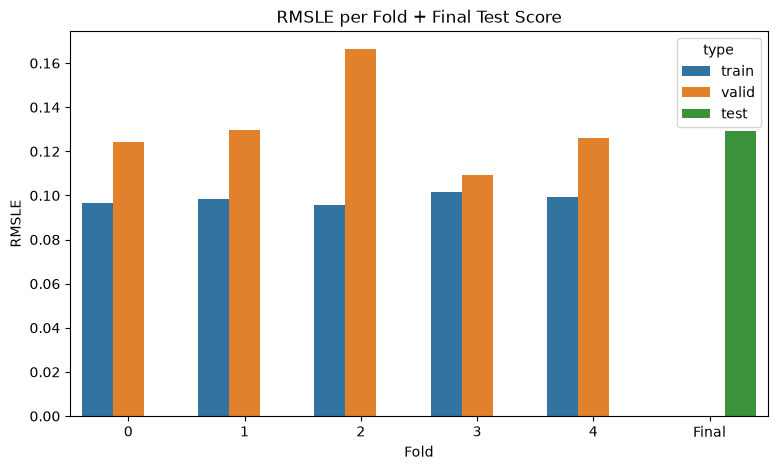

In [11]:
base_model = Pipeline([
    ("prep", preprocessor),
    ("elasticnet", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000))
])
model = TransformedTargetRegressor(
    regressor=base_model,
    transformer=log_standardize_y,
    check_inverse=False
)

folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)
result = cross_validate(
    model, X_train, y_train,
    cv=cv,
    scoring="neg_root_mean_squared_log_error",
    return_train_score=True,
)

# スコア表示
train_scores = -result["train_score"]
valid_scores = -result["test_score"]

for i, (tr, va) in enumerate(zip(train_scores, valid_scores), 1):
    print(f"Fold {i}: train RMSLE = {tr:.4f} / valid RMSLE = {va:.4f}")
print(f"CV平均: train {train_scores.mean():.4f} / valid {valid_scores.mean():.4f}")

model.fit(X_train, y_train)
test_score = root_mean_squared_log_error(y_va, model.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score:.4f}")

# スコアグラフ
df = pl.DataFrame({
    "Fold": [str(i) for i in range(folds)] * 2 + ["Final"],
    "RMSLE": list(train_scores) + list(valid_scores) + [test_score],
    "type": ["train"] * folds + ["valid"] * folds + ["test"],
})

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Fold", y="RMSLE", hue="type")
plt.title("RMSLE per Fold + Final Test Score")
plt.show()


### grid search

In [ ]:
param_grid = {
    "regressor__elasticnet__alpha": [0.0001, 0.001, 0.01, 0.1],
    "regressor__elasticnet__l1_ratio": [0.1, 0.3, 0.5, 0.7],
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_log_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV RMSLE: {-grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
test_score_gs = root_mean_squared_log_error(y_va, best_model.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_gs:.4f}")

# alphaごとのCVスコア一覧
cv_results = pd.DataFrame(grid_search.cv_results_)[
    ["param_regressor__elasticnet__alpha", "param_regressor__elasticnet__l1_ratio", "mean_test_score", "std_test_score"]
].assign(
    mean_test_RMSLE=lambda df: -df["mean_test_score"]
).sort_values("param_regressor__elasticnet__alpha")
cv_results


Best params: {'regressor__elasticnet__alpha': 0.01, 'regressor__elasticnet__l1_ratio': 0.5}
Best CV RMSLE: 0.1288
最終スコア(test RMSLE): 0.1268


,param_regressor__elasticnet__alpha,param_regressor__elasticnet__l1_ratio,mean_test_score,std_test_score,mean_test_RMSLE
0,0.0001,0.1,-0.134507,0.019679,0.134507
1,0.0001,0.3,-0.134429,0.019646,0.134429
2,0.0001,0.5,-0.134113,0.019707,0.134113
3,0.0001,0.7,-0.133909,0.019558,0.133909
4,0.0001,0.9,-0.133540,0.019808,0.133540
5,0.0001,1.0,-0.133592,0.019554,0.133592
6,0.0010,0.1,-0.132332,0.019108,0.132332
7,0.0010,0.3,-0.131524,0.019132,0.131524
8,0.0010,0.5,-0.131034,0.018946,0.131034
9,0.0010,0.7,-0.130539,0.018996,0.130539


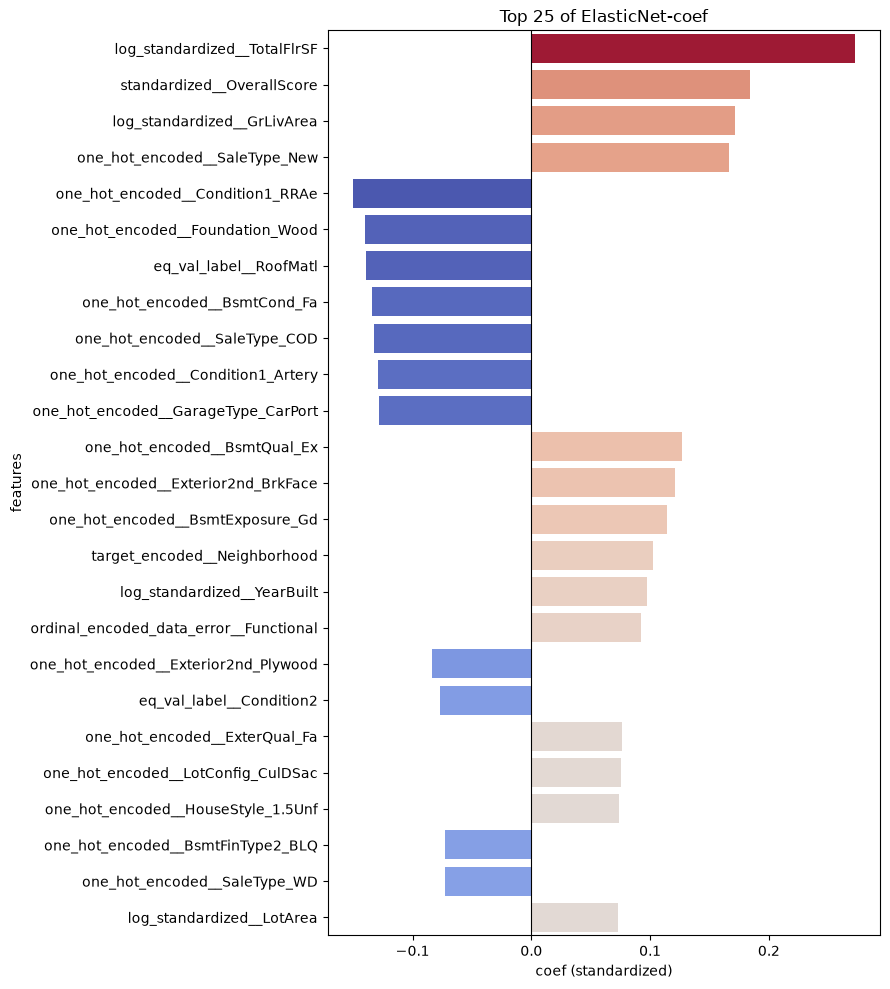

In [13]:
# 特徴量の寄与度（ElasticNet係数）トップ25
feature_names = model.regressor_.named_steps["prep"].get_feature_names_out()
coefs = model.regressor_.named_steps["elasticnet"].coef_

importance_df = pl.DataFrame({
    "feature": feature_names,
    "coef": coefs,
}).with_columns(
    pl.col("coef").abs().alias("abs_coef")
).sort("abs_coef", descending=True).head(25)

plt.figure(figsize=(9, 10))
sns.barplot(
    data=importance_df.to_pandas(),
    x="coef", y="feature",
    hue="coef", palette="coolwarm", dodge=False, legend=False,
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 25 of ElasticNet-coef")
plt.xlabel("coef (standardized)")
plt.ylabel("features")
plt.tight_layout()
plt.show()


### submit

In [14]:
from sklearn.base import clone

# ベストハイパーパラメータで全学習データ(X, y)を使って最終学習
final_model = clone(model)
final_model.set_params(**grid_search.best_params_)
final_model.fit(X, y)

submit_df = pl.DataFrame({
    "Id": test['Id'],
    "SalePrice": final_model.predict(X_test)
})


In [15]:
submit_df.write_csv("../submit.csv")